In [1]:
import numpy as np
import networkx as nx

import os

from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.iterative_searcher import IterativeSearcher

from recover_dwave_inspector_data import recover_dwave_inspector_problems_from_runs


%load_ext autoreload
%autoreload 2

In [2]:
er_169 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_169.npy", allow_pickle=True)[0]

In [ ]:
results_dir = f"ER/resolution-1/graphs-1_p-0.4/runs-55-extra/erdos-renyi_169"
# os.makedirs(results_dir, exist_ok=True)

In [11]:
num_reads = 100
num_runs = 20

In [12]:
G = er_169
graph_size = G.number_of_nodes()
assert graph_size == 169
assert results_dir.endswith("runs-55-extra/erdos-renyi_169")

saving_path = f"{results_dir}/graph_size={graph_size}"
os.makedirs(saving_path, exist_ok=True)
problems_saving_path=f"{saving_path}/problems"
os.makedirs(problems_saving_path, exist_ok=True)

# 2. Create Advantage Sampler
adv_sampler = AdvantageSampler(G, num_reads=num_reads, version="Advantage_system6.4", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True, saving_path=problems_saving_path, label="erdos-renyi_169-runs-55-extra")
it_searcher = IterativeSearcher(adv_sampler)

# 3. Run the hierarchical process 5 times
results = it_searcher.run_with_sampleset_info(num_runs=55, saving_path=f"{saving_path}/er_p=0.4", return_metadata=True)

# # 4. Recover and save D-Wave Inspector problem storage
dwave_inspector_storage_path = f"{saving_path}/recovery_dwave_inspector"
os.makedirs(dwave_inspector_storage_path, exist_ok=True)
recover_dwave_inspector_problems_from_runs(results, base_path=dwave_inspector_storage_path)

100%|██████████| 55/55 [03:58<00:00,  4.34s/it]


In [20]:
from iterative_utils import IterativeSearchGraphResults
from Qommunity.searchers.utils import HierarchicalRunMetadata
from saving_utils import parse_response_json


graphs_results_er = {}

num_runs = 20
g_size = 169
results_dir_er = f"ER/resolution-1/graphs-1_p-0.4/runs-20/erdos-renyi_169/"
graphs_results_path_base = results_dir_er + f"/graph_size={g_size}/er-1_p-0.4"

hierarchical_metadatas = []
# Original runs
path = results_dir_er + f"/graph_size={g_size}"
for iter in range(num_runs):
    base_filename = f"{path}/er_p=0.4"+f"_iter_{iter}"
    hm = HierarchicalRunMetadata.load_from_files(base_filename)
    hierarchical_metadatas.append(hm)
communities = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
modularities = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
times = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
division_modularities = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
division_trees = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)

# First extra runs
path = f"ER/resolution-1/graphs-1_p-0.4/" + f"/graph_size={g_size}"
for iter in range(num_runs):
    base_filename = f"{path}/er_p=0.4"+f"_iter_{iter}"
    hm = HierarchicalRunMetadata.load_from_files(base_filename)
    hierarchical_metadatas.append(hm)

path = results_dir_er + f"/graph_size={g_size}/"
communities_2 = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
modularities_2 = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
times_2 = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
division_modularities_2 = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
division_trees_2 = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)

communities = np.concatenate((communities, communities_2), axis=0)
modularities = np.concatenate((modularities, modularities_2), axis=0)
times = np.concatenate((times, times_2), axis=0)
division_modularities = np.concatenate((division_modularities, division_modularities_2), axis=0)
division_trees = np.concatenate((division_trees, division_trees_2), axis=0)

# Second extra runs
path = f"ER/resolution-1/graphs-1_p-0.4/runs-20/erdos-renyi_169" + f"/graph_size={g_size}"
for iter in range(num_runs):
    base_filename = f"{path}/er_p=0.4"+f"_iter_{iter}"
    hm = HierarchicalRunMetadata.load_from_files(base_filename)
    hierarchical_metadatas.append(hm)

path = results_dir_er + f"/graph_size={g_size}/"
communities_3 = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
modularities_3 = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
times_3 = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
division_modularities_3 = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
division_trees_3 = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)

communities = np.concatenate((communities, communities_3), axis=0)
modularities = np.concatenate((modularities, modularities_3), axis=0)
times = np.concatenate((times, times_3), axis=0)
division_modularities = np.concatenate((division_modularities, division_modularities_3), axis=0)
division_trees = np.concatenate((division_trees, division_trees_3), axis=0)


# Third extra runs
path = f"ER/resolution-1/graphs-1_p-0.4/runs-20-extra/erdos-renyi_169" + f"/graph_size={g_size}"
for iter in range(num_runs):
    base_filename = f"{path}/er_p=0.4"+f"_iter_{iter}"
    hm = HierarchicalRunMetadata.load_from_files(base_filename)
    hierarchical_metadatas.append(hm)

path = results_dir_er + f"/graph_size={g_size}/"
communities_4 = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
modularities_4 = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
times_4 = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
division_modularities_4 = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
division_trees_4 = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)

communities = np.concatenate((communities, communities_4), axis=0)
modularities = np.concatenate((modularities, modularities_4), axis=0)
times = np.concatenate((times, times_4), axis=0)
division_modularities = np.concatenate((division_modularities, division_modularities_4), axis=0)
division_trees = np.concatenate((division_trees, division_trees_4), axis=0)


# Fourth extra runs
path = f"ER/resolution-1/graphs-1_p-0.4/runs-55-extra/erdos-renyi_169" + f"/graph_size={g_size}"
for iter in range(num_runs):
    base_filename = f"{path}/er_p=0.4"+f"_iter_{iter}"
    hm = HierarchicalRunMetadata.load_from_files(base_filename)
    hierarchical_metadatas.append(hm)
path = results_dir_er + f"/graph_size={g_size}/"
communities_5 = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
modularities_5 = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
times_5 = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
division_modularities_5 = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
division_trees_5 = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)

communities = np.concatenate((communities, communities_4), axis=0)
modularities = np.concatenate((modularities, modularities_4), axis=0)
times = np.concatenate((times, times_4), axis=0)
division_modularities = np.concatenate((division_modularities, division_modularities_4), axis=0)
division_trees = np.concatenate((division_trees, division_trees_4), axis=0)

communities = np.concatenate((communities, communities_5), axis=0)
modularities = np.concatenate((modularities, modularities_5), axis=0)
times = np.concatenate((times, times_5), axis=0)
division_modularities = np.concatenate((division_modularities, division_modularities_5), axis=0)
division_trees = np.concatenate((division_trees, division_trees_5), axis=0)


# Fifth extra runs
path = f"ER/resolution-1/graphs-1_p-0.4/runs-5-extra/erdos-renyi_169" + f"/graph_size={g_size}"
for iter in range(5):
    base_filename = f"{path}/er_p=0.4"+f"_iter_{iter}"
    hm = HierarchicalRunMetadata.load_from_files(base_filename)
    hierarchical_metadatas.append(hm)
path = results_dir_er + f"/graph_size={g_size}/"
communities_6 = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
modularities_6 = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
times_6 = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
division_modularities_6 = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
division_trees_6 = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)

communities = np.concatenate((communities, communities_6), axis=0)
modularities = np.concatenate((modularities, modularities_6), axis=0)
times = np.concatenate((times, times_6), axis=0)
division_modularities = np.concatenate((division_modularities, division_modularities_6), axis=0)
division_trees = np.concatenate((division_trees, division_trees_6), axis=0)

iterative_graph_results = IterativeSearchGraphResults(
    graph_ref = G,
    graph_size=g_size,
    communities = communities,
    modularities = modularities,
    times = times,
    division_modularities = division_modularities,
    division_trees = division_trees,
    hierarchical_metadatas=hierarchical_metadatas
)

graphs_results_er[g_size] = iterative_graph_results

In [72]:
# Erdos-Renyi
hierarchical_metadata_er = graphs_results_er[169].hierarchical_metadatas
# cbfs = np.empty((105, ), dtype=object)
# for i in range(105):
#     cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata_er[i]])
modularities_er = graphs_results_er[169].modularities
communities_er = graphs_results_er[169].communities
cbfs_sums_er = graphs_results_er[169].cbfs_sum_per_run

# Erdos-Renyi
mods_er = []
cbf_max_er = []
cbf_avg_er = []
non_zero_cbfs_er = []
chain_strengths_er = []
comms_lens_er = []
energies_er = []
indices_er = []

for idx, sm in enumerate(hierarchical_metadata_er):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    cbf_max_er.append(cbfs.max())
    cbf_avg_er.append(cbfs.mean())
    non_zero_cbfs_er.append(cbfs[non_zero_cbfs_idxs])
    indices_er.append(non_zero_cbfs_idxs)

    chain_strengths_er.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods_er.append(modularities_er[idx])
    comms_lens_er.append(len(communities_er[idx]))

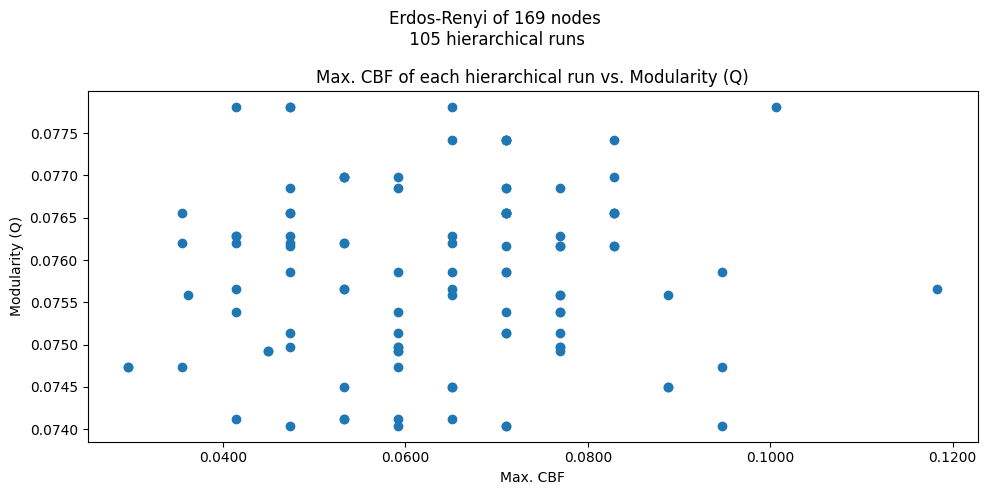

In [83]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 1, figsize=(10, 5))
fig.suptitle("Erdos-Renyi of 169 nodes\n 105 hierarchical runs")

sc = ax.scatter(cbf_max_er, mods_er)
ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Max. CBF")
ax.set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

ax.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()

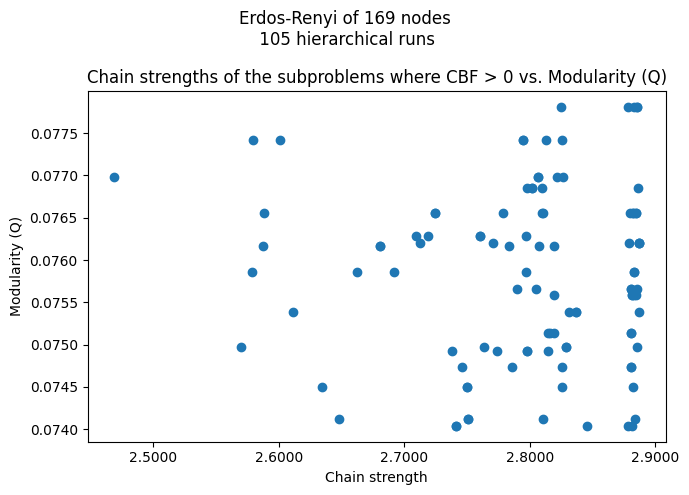

In [49]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle("Erdos-Renyi of 169 nodes\n 105 hierarchical runs")

ax.scatter(chain_strengths_er, mods_er)
ax.set_ylabel("Modularity (Q)")
ax.set_xlabel("Chain strength")
ax.set_title("Chain strengths of the subproblems where CBF > 0 vs. Modularity (Q)");

ax.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()

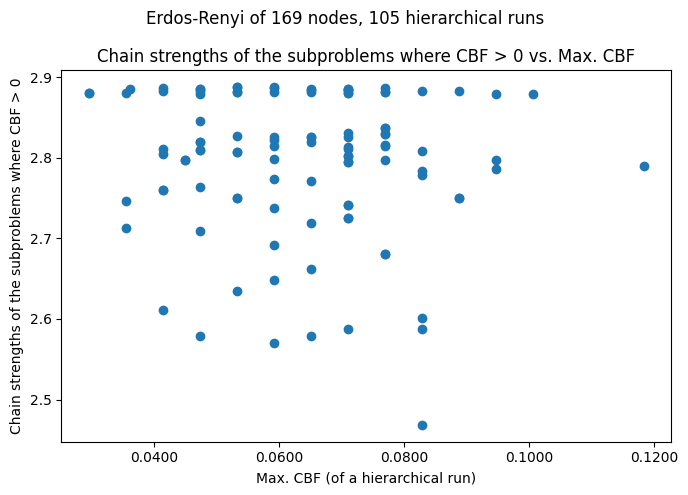

In [55]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle("Erdos-Renyi of 169 nodes, 105 hierarchical runs")

ax.scatter(cbf_max_er, chain_strengths_er)
ax.set_ylabel("Chain strengths of the subproblems where CBF > 0")
ax.set_xlabel("Max. CBF (of a hierarchical run)")
ax.set_title("Chain strengths of the subproblems where CBF > 0 vs. Max. CBF");

ax.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()

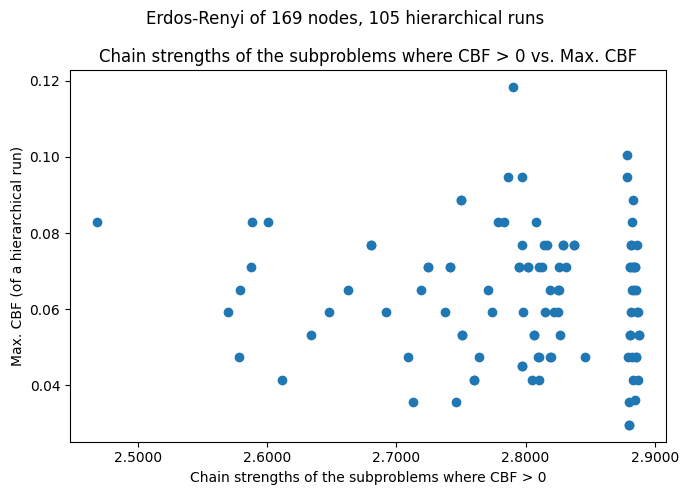

In [58]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle("Erdos-Renyi of 169 nodes, 105 hierarchical runs")

ax.scatter(chain_strengths_er, cbf_max_er)
ax.set_ylabel("Max. CBF (of a hierarchical run)")
ax.set_xlabel("Chain strengths of the subproblems where CBF > 0")
ax.set_title("Chain strengths of the subproblems where CBF > 0 vs. Max. CBF");

ax.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()

In [9]:
G = er_169
graph_size = G.number_of_nodes()
assert graph_size == 169
saving_path = f"{results_dir}/graph_size={graph_size}"
os.makedirs(saving_path, exist_ok=True)

# 2. Create Advantage Sampler
adv_sampler = AdvantageSampler(G, num_reads=num_reads, version="Advantage_system6.4", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True, saving_path=f"{saving_path}/problems/", label="erdos-renyi_169")
it_searcher = IterativeSearcher(adv_sampler)

# 3. Run the hierarchical process 20 times
results = it_searcher.run_with_sampleset_info(num_runs=1, saving_path=f"{saving_path}/er_p=0.4", return_metadata=True)

# 4. Recover and save D-Wave Inspector problem storage
dwave_inspector_storage_path = f"{saving_path}/recovery_dwave_inspector"
os.makedirs(dwave_inspector_storage_path, exist_ok=True)
recover_dwave_inspector_problems_from_runs(results, base_path=dwave_inspector_storage_path)

100%|██████████| 1/1 [00:34<00:00, 34.83s/it]


In [51]:
# Iterate over graphs of different sizes
for i, G in enumerate(graphs_110_160[:2]):
    # 1. Create directory for results
    graph_size = G.number_of_nodes()
    saving_path = f"{results_dir}/graph_size={graph_size}"
    os.makedirs(saving_path, exist_ok=True)

    # 2. Create Advantage Sampler
    adv_sampler = AdvantageSampler(G, num_reads=num_reads, version="Advantage_system6.4", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)
    it_searcher = IterativeSearcher(adv_sampler)

    # 3. Run the hierarchical process 20 times
    results = it_searcher.run_with_sampleset_info(num_runs=num_runs, saving_path=f"{saving_path}/er_p=0.4", return_metadata=True)

    # 4. Recover and save D-Wave Inspector problem storage
    dwave_inspector_storage_path = f"{saving_path}/recovery_dwave_inspector"
    os.makedirs(dwave_inspector_storage_path, exist_ok=True)
    recover_dwave_inspector_problems_from_runs(results, base_path=dwave_inspector_storage_path)

100%|██████████| 20/20 [10:38<00:00, 31.94s/it]


In [54]:
graphs_110_160

In [53]:
graphs_110_160[:2]

In [63]:
graphs_110_160[2:3][0].number_of_nodes()

130

In [8]:
# Iterate over graphs of different sizes
for i, G in enumerate(graphs_110_160[5:6]):
    # 1. Create directory for results
    graph_size = G.number_of_nodes()
    saving_path = f"{results_dir}/graph_size={graph_size}"
    os.makedirs(saving_path, exist_ok=True)

    # 2. Create Advantage Sampler
    adv_sampler = AdvantageSampler(G, num_reads=num_reads, version="Advantage_system6.4", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)
    it_searcher = IterativeSearcher(adv_sampler)

    # 3. Run the hierarchical process 20 times
    results = it_searcher.run_with_sampleset_info(num_runs=num_runs, saving_path=f"{saving_path}/er_p=0.4", return_metadata=True)

    # 4. Recover and save D-Wave Inspector problem storage
    dwave_inspector_storage_path = f"{saving_path}/recovery_dwave_inspector"
    os.makedirs(dwave_inspector_storage_path, exist_ok=True)
    recover_dwave_inspector_problems_from_runs(results, base_path=dwave_inspector_storage_path)

100%|██████████| 20/20 [08:32<00:00, 25.61s/it]


In [10]:
# Iterate over graphs of different sizes
for i, G in enumerate(graphs):
    # 1. Create directory for results
    graph_size = G.number_of_nodes()
    saving_path = f"{results_dir}/graph_size={graph_size}"
    os.makedirs(saving_path, exist_ok=True)

    # 2. Create Advantage Sampler
    adv_sampler = AdvantageSampler(G, num_reads=num_reads, version="Advantage_system6.4", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)
    it_searcher = IterativeSearcher(adv_sampler)

    # 3. Run the hierarchical process 20 times
    results = it_searcher.run_with_sampleset_info(num_runs=num_runs, saving_path=f"{saving_path}/er_p=0.4", return_metadata=True)

    # 4. Recover and save D-Wave Inspector problem storage
    dwave_inspector_storage_path = f"{saving_path}/recovery_dwave_inspector"
    os.makedirs(dwave_inspector_storage_path, exist_ok=True)
    recover_dwave_inspector_problems_from_runs(results, base_path=dwave_inspector_storage_path)

100%|██████████| 20/20 [15:05<00:00, 45.29s/it]


In [ ]:
from saving_utils import parse_response_json #, deserialize_qubo_problem

In [18]:
from dataclasses import dataclass, field
from saving_utils import parse_response_json, deserialize_qubo_problem
from searchers.utils import HierarchicalRunMetadata

@dataclass
class IterativeSearchGraphResults:
    graph_ref: nx.Graph
    graph_size: int
    communities: np.ndarray[list[list[int]]]
    modularities: np.ndarray[float]
    times: np.ndarray[float]
    division_modularities: np.ndarray[list[float]]
    division_trees: np.ndarray[list[list[int]]]
    hierarchical_metadatas: list[HierarchicalRunMetadata]

    cbfs: np.ndarray[object] = field(init=False)

    def __post_init__(self):
        cbfs = np.empty((len(self.hierarchical_metadatas),), dtype=object)
        for i, iterative_run in enumerate(self.hierarchical_metadatas):
            cbfs[i] = np.array([hm.chain_break_fraction for hm in iterative_run])
        self.cbfs = cbfs

    @property
    def chain_break_fractions(self) -> np.ndarray[float]:
        all_cbfs = np.concatenate(self.cbfs)
        return all_cbfs


    # CBFS maxes and means per hierarchical run
    @property
    def cbfs_maxes(self) -> np.ndarray[float]:
        cbfs_maxes = [np.max(cbfs_in_run) for cbfs_in_run in self.cbfs]
        return cbfs_maxes
    
    @property
    def cbfs_means(self) -> np.ndarray[float]:
        cbfs_means = [np.mean(cbfs_in_run) for cbfs_in_run in self.cbfs]
        return cbfs_means
    
    @property
    def cbfs_sum_per_run(self) -> np.ndarray[float]:
        cbfs_sums = [np.sum(cbfs_in_run) for cbfs_in_run in self.cbfs]
        return cbfs_sums
    
    # CBFS indexes of maxes and means in hierarchical runs
    @property
    def cbfs_hierarchical_indexes_of_max(self) -> np.ndarray[int]:
        cbfs_hierarchical_indexes_of_max = [np.argmax(cbfs_in_run) for cbfs_in_run in self.cbfs]
        return cbfs_hierarchical_indexes_of_max
    
    @property
    def cbfs_hierarchical_indexes_of_means(self) -> np.ndarray[int]:
        cbfs_hierarchical_indexes_of_mean = [np.argmax(cbfs_in_run) for cbfs_in_run in self.cbfs]
        return cbfs_hierarchical_indexes_of_mean

In [13]:
results_dir

'ER/resolution-1/graphs-1_p-0.4'

In [25]:
from Qommunity.searchers.utils import HierarchicalRunMetadata

graphs_results = {}

num_runs = 20
graph_sizes = np.arange(10, 170, 10).tolist() + [169]


for g_size in graph_sizes:
    graphs_results_path_base = results_dir + f"/graph_size={g_size}/er-1_p-0.4"
    hierarchical_metadatas = []
    
    path = results_dir + f"/graph_size={g_size}"
    for iter in range(num_runs):
        base_filename = f"{path}/er_p=0.4"+f"_iter_{iter}"
        hm = HierarchicalRunMetadata.load_from_files(base_filename)
        hierarchical_metadatas.append(hm)

    path = results_dir + f"/graph_size={g_size}/"
    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref = graphs[graph_sizes.index(g_size)],
        graph_size=g_size,
        communities = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True),
        modularities = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True),
        times = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True),
        division_modularities = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True),
        division_trees = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True),
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results[g_size] = iterative_graph_results

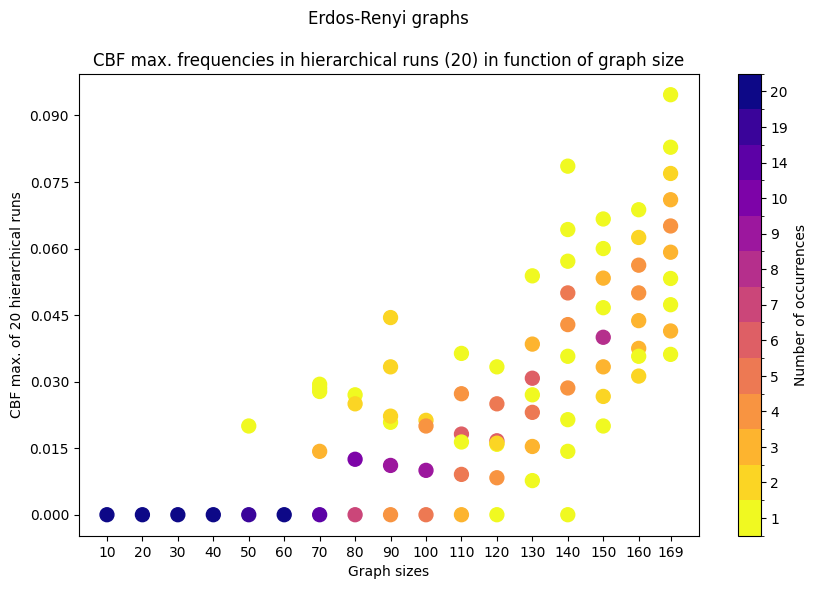

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm

cbfs_maxes_per_graph_size = [graphs_results[g_size].cbfs_maxes for g_size in graph_sizes]
xs = [[g_size] * num_runs for g_size in graph_sizes]

all_ys = np.unique(np.concatenate(cbfs_maxes_per_graph_size))
all_x = []
all_y = []
all_counts = []

for x_row, y_row in zip(xs, cbfs_maxes_per_graph_size):
    counts = Counter(y_row)
    for y_val, count in counts.items():
        all_x.append(x_row[0])
        all_y.append(y_val)
        all_counts.append(count)

unique_counts = sorted(set(all_counts))

cmap = ListedColormap(plt.get_cmap("plasma_r")(np.linspace(0,1,len(unique_counts))))
norm = BoundaryNorm(boundaries=np.arange(len(unique_counts)+1)-0.5, ncolors=len(unique_counts))

color_indices = [unique_counts.index(c) for c in all_counts]

fig, ax = plt.subplots(figsize=(10,6))

scatter = ax.scatter(all_x, all_y, c=color_indices, cmap=cmap, norm=norm, s=100)

ax.set_title("Erdos-Renyi graphs\n\nCBF max. frequencies in hierarchical runs (20) in function of graph size")
ax.set_xticks(graph_sizes)
ax.set_yticks(all_ys)
ax.set_xlabel("Graph sizes")
ax.set_ylabel("CBF max. of 20 hierarchical runs")

ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

cbar = plt.colorbar(scatter, ticks=range(len(unique_counts)))
cbar.ax.set_yticklabels(unique_counts)
cbar.set_label("Number of occurrences")

plt.show()


In [30]:
hierarchical_metadata = graphs_results[169].hierarchical_metadatas
cbfs = np.empty((20, ), dtype=object)
for i in range(20):
    cbfs[i] = np.array([hm.chain_break_fraction for hm in hierarchical_metadata[i]])
modularities = graphs_results[169].modularities
communities = graphs_results[169].communities
cbfs_sums = graphs_results[169].cbfs_sum_per_run

In [31]:
mods = []
cbf_max = []
cbf_avg = []
non_zero_cbfs = []
chain_strengths = []
comms_lens = []
energies = []
indices = []

for idx, sm in enumerate(hierarchical_metadatas):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    cbf_max.append(cbfs.max())
    cbf_avg.append(cbfs.mean())
    non_zero_cbfs.append(cbfs[non_zero_cbfs_idxs])
    indices.append(non_zero_cbfs_idxs)

    chain_strengths.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods.append(modularities[idx])
    comms_lens.append(communities[idx])

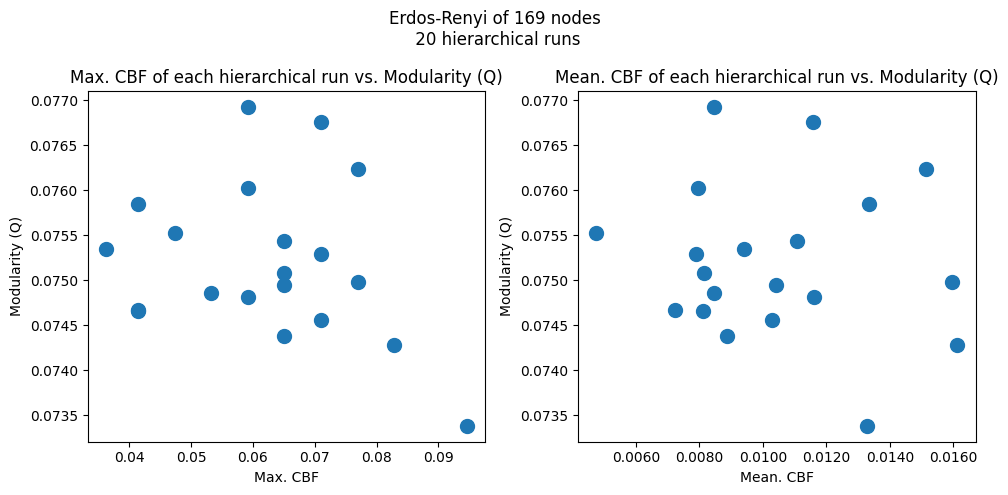

: 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Erdos-Renyi of 169 nodes\n 20 hierarchical runs")

ax[0].scatter(cbf_max, mods, s=100)
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

ax[1].scatter(cbf_avg, mods, s=100)
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of each hierarchical run vs. Modularity (Q)");

ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.show()